In [1]:
import numpy as np

In [2]:
D = np.array([
    [3, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 2, 0],
    [0, 0, 0, 2],
])

D

array([[3, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 2, 0],
       [0, 0, 0, 2]])

by definition, D gives us the degree of each node, deg(i). Therefore, the inverse of this matrix D^-1 directly gives us the normalisation coeff --> 1 / deg(i):

In [3]:
np.linalg.inv(D)

array([[0.33333333, 0.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        , 0.        ],
       [0.        , 0.        , 0.5       , 0.        ],
       [0.        , 0.        , 0.        , 0.5       ]])

In [4]:
np.linalg.inv(D + np.identity(4))

array([[0.25      , 0.        , 0.        , 0.        ],
       [0.        , 0.5       , 0.        , 0.        ],
       [0.        , 0.        , 0.33333333, 0.        ],
       [0.        , 0.        , 0.        , 0.33333333]])

In [5]:
# adjacency matrix
A = np.array([
    [1, 1, 1, 1],
    [1, 1, 0, 0],
    [1, 0, 1, 1],
    [1, 0, 1, 1]
])

In [6]:
print(np.linalg.inv(D + np.identity(4)) @ A) # doing matrix multiplication using the '@' operator

[[0.25       0.25       0.25       0.25      ]
 [0.5        0.5        0.         0.        ]
 [0.33333333 0.         0.33333333 0.33333333]
 [0.33333333 0.         0.33333333 0.33333333]]


In [7]:
print(A @ np.linalg.inv(D + np.identity(4)))

[[0.25       0.5        0.33333333 0.33333333]
 [0.25       0.5        0.         0.        ]
 [0.25       0.         0.33333333 0.33333333]
 [0.25       0.         0.33333333 0.33333333]]


# Comparing Graph Convolutional and Graph Linear layers

In [8]:
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import degree
from collections import Counter
import matplotlib.pyplot as plt

e:\Experimental Projects\advanced_gnn\gnn_venv\lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
e:\Experimental Projects\advanced_gnn\gnn_venv\lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
e:\Experimental Projects\advanced_gnn\gnn_venv\lib\site-packages\torch_geometric\typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(
e:\Experimental Projects\advanced_gnn\gnn_venv\lib\site-packages\torch_geometric\typin

In [9]:
# the Cora dataset is imported and its graph is stored in data
dataset = Planetoid(root = ".", name = "Cora")
data = dataset[0]
print(data)

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [10]:
# we compute the number of neighbours of each node in the graph
degrees = degree(data.edge_index[0]).numpy()
print(degrees)

[3. 3. 5. ... 1. 4. 4.]


In [11]:
# to produce a more natural visualisation, we count the number of nodes for each degree:
numbers = Counter(degrees)
print(numbers)

Counter({2.0: 583, 3.0: 553, 1.0: 485, 4.0: 389, 5.0: 281, 6.0: 131, 7.0: 82, 8.0: 57, 10.0: 26, 9.0: 25, 12.0: 18, 11.0: 14, 17.0: 8, 16.0: 7, 14.0: 6, 15.0: 6, 19.0: 5, 13.0: 5, 21.0: 3, 18.0: 3, 23.0: 3, 32.0: 2, 30.0: 2, 36.0: 1, 78.0: 1, 33.0: 1, 29.0: 1, 34.0: 1, 26.0: 1, 168.0: 1, 22.0: 1, 42.0: 1, 74.0: 1, 44.0: 1, 31.0: 1, 65.0: 1, 40.0: 1})


<BarContainer object of 37 artists>

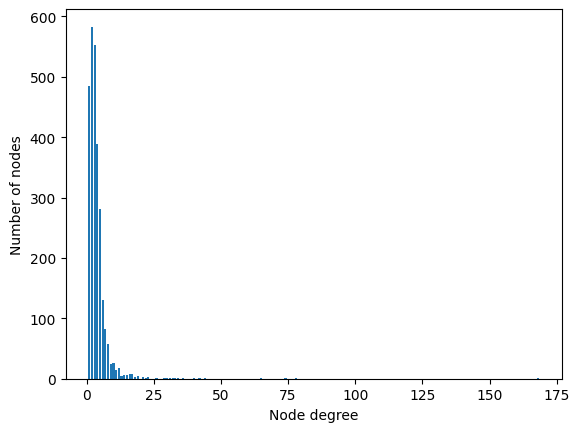

In [12]:
# let's plot the result using a bar plot
fig, ax = plt.subplots()
ax.set_xlabel("Node degree")
ax.set_ylabel("Number of nodes")
plt.bar(numbers.keys(), numbers.values())

Thsi distribution looks exponential with a heavy tail: it ranges from 1 neighbour (485 nodes) to 168 neighbours (1 node)! this is exactly the kind of dataset where we want a normalisation process to consider this disbalance.

PyTorch Geometric already has a predefined GCN layer.

In [13]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

In [14]:
# a method to calculate the accuracy score:
def accuracy(pred_y, y):
    return ((pred_y == y).sum() / len(y)).item()

We now create a GCN class with a `__init__()` function that takes 3 parameters as input: the number of input dimensions `dim_in`, the number of hidden dimensions `dim_h`, and the number of output dimensions `dim_out`:

In [15]:
class GCN(torch.nn.Module):
    """Graph Convolutional Network"""
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.gcn1 = GCNConv(dim_in, dim_h)
        self.gcn2 = GCNConv(dim_h, dim_out)

    def forward(self, x, edge_index):
        h = self.gcn1(x, edge_index)
        h = torch.relu(h)
        h = self.gcn2(h, edge_index)
        return F.log_softmax(h, dim=1)

    def fit(self, data, epochs):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(),
                                      lr=0.01,
                                      weight_decay=5e-4)

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x, data.edge_index)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1),
                          data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if(epoch % 20 == 0):
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1),
                                  data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc:'
                      f' {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | '
                      f'Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x, data.edge_index)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc

In [16]:
gcn = GCN(dataset.num_features, 16, dataset.num_classes)
print(gcn)

# train
gcn.fit(data, epochs = 100)

GCN(
  (gcn1): GCNConv(1433, 16)
  (gcn2): GCNConv(16, 7)
)
Epoch   0 | Train Loss: 1.941 | Train Acc: 19.29% | Val Loss: 1.95 | Val Acc: 19.20%
Epoch  20 | Train Loss: 0.113 | Train Acc: 100.00% | Val Loss: 0.85 | Val Acc: 75.00%
Epoch  40 | Train Loss: 0.015 | Train Acc: 100.00% | Val Loss: 0.83 | Val Acc: 74.80%
Epoch  60 | Train Loss: 0.015 | Train Acc: 100.00% | Val Loss: 0.79 | Val Acc: 75.80%
Epoch  80 | Train Loss: 0.017 | Train Acc: 100.00% | Val Loss: 0.77 | Val Acc: 76.20%
Epoch 100 | Train Loss: 0.016 | Train Acc: 100.00% | Val Loss: 0.76 | Val Acc: 76.20%


In [17]:
# test
acc = gcn.test(data)
print(f"\nGCN test accuracy: {acc*100:.2f}%\n")


GCN test accuracy: 79.10%



# predicting web traffic with node regression

the dataset we will use is the **Wikipedia Network** which contains 3 page-page networks:
- chameleons (2,777 nodes and 31,421 edges),
- crocodiles (11,631 nodes and 170,918 edges),
- squirrels (5,201 nodes and 198,492 edges).

in these datsets, nodes represent articles and edges are mutual links betweeen them. node features reflect the presence of partiuclar words in the articles. finally, the goal is to predict the log average monthly traffic of December 2018.

In [18]:
# import the wikipedia network and download the dataset

from torch_geometric.datasets import WikipediaNetwork
import torch_geometric.transforms as T

dataset = WikipediaNetwork(root = ".", name = "chameleon", transform = T.RandomNodeSplit(num_val = 200, num_test = 500))
data = dataset[0]
print(data)

Processing...


Data(x=[2277, 2325], edge_index=[2, 36101], y=[2277], train_mask=[2277], val_mask=[2277], test_mask=[2277])


Done!


In [19]:
print(f'Dataset: {dataset}')
print('-------------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes: {data.x.shape[0]}')
print(f'Number of unique features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

Dataset: WikipediaNetwork()
-------------------
Number of graphs: 1
Number of nodes: 2277
Number of unique features: 2325
Number of classes: 5


there is a problem with out dataset: the output says that we have 5 classes. however, we ant to perform node regression, not classification. in fact, these 5 classes are bins of the cts values we want to predict. so will have to manually download the file.

I have downloaded and unzipped it in this folder

In [20]:
import pandas as pd

df = pd.read_csv('wikipedia/wikipedia/chameleon/musae_chameleon_target.csv')
df.head()

,id,target
0,0,171
1,1,8089
2,2,8568
3,3,47178
4,4,3634


now we, apply a log function to the target values using `np.log10()` because the goal is to predict the log average monthly traffic:

In [21]:
values = np.log10(df['target'])
values

0       2.232996
1       3.907895
2       3.932879
3       4.673740
4       3.560385
          ...   
2272    4.497179
2273    3.433930
2274    1.995635
2275    4.359798
2276    2.440909
Name: target, Length: 2277, dtype: float64

we redefine `data.y` as a tensor of the cts values from the previous step. note that these values are not normalised in this example, which is a good practive that is usually implemented. we will not perform it here for the ease of exposition:

In [22]:
data.y = torch.tensor(values)
data.y

tensor([2.2330, 3.9079, 3.9329,  ..., 1.9956, 4.3598, 2.4409],
       dtype=torch.float64)

in case of node regression, the distribution of node degrees is not the only type of dist we should check: the dist of our target values is also essential. 

C:\Users\Abin\AppData\Local\Temp\ipykernel_16776\1819461436.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['target'], fit = norm)


<Axes: xlabel='target', ylabel='Density'>

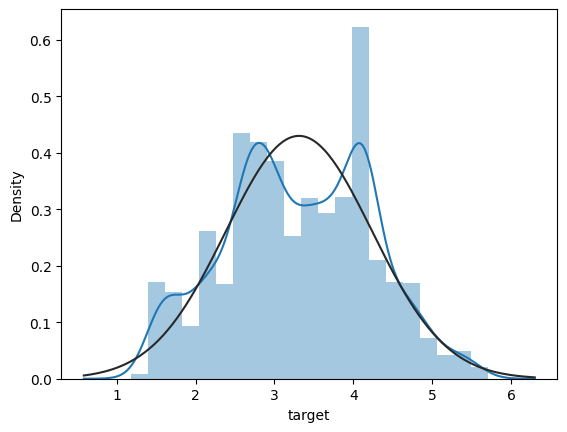

In [28]:
import seaborn as sns
from scipy.stats import norm
df['target'] = values
sns.distplot(df['target'], fit = norm)

this distribution is not exactly normal, but it is also not exponential like the node degrees either. we can expect our model to perform well to predict these values

we define the GCN class adn the `__init__()` method. this time, we have 3 GCNConv layers with a decreasing number of neurons. the idea behind this encoder architecture is to force the model to selevt the most relevant features to predict the target values. we also add a linear layer to output a prediction that is not limited to a number between 0 or -1 and 1:

In [30]:
class GCN(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.gcn1 = GCNConv(dim_in, dim_h * 4)
        self.gcn2 = GCNConv(dim_h * 4, dim_h * 2)
        self.gcn3 = GCNConv(dim_h * 2, dim_h)
        self.linear = torch.nn.Linear(dim_h, dim_out)

    def forward(self, x, edge_index):
        h = self.gcn1(x, edge_index)
        h = torch.relu(h)
        h = F.dropout(h, p = 0.5, training = self.training)
        h = self.gcn2(h, edge_index)
        h = torch.relu(h)
        h = F.dropout(h, p = 0.5, training = self.training)
        h = self.gcn3(h, edge_index)
        h = torch.relu(h)
        h = self.linear(h)
        return h
    
    def fit(self, data, epochs): 
        optimizer = torch.optim.Adam(self.parameters(),
                                      lr=0.02,
                                      weight_decay=5e-4)

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x, data.edge_index)
            loss = F.mse_loss(out.squeeze()[data.train_mask], data.y[data.train_mask].float())
            loss.backward()
            optimizer.step()
            if epoch % 20 == 0:
                val_loss = F.mse_loss(out.squeeze()[data.val_mask], data.y[data.val_mask])
                print(f"Epoch {epoch:>3} | Train Loss: {loss:.5f} | Val Loss: {val_loss:.5f}")

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x, data.edge_index)
        return F.mse_loss(out.squeeze()[data.test_mask], data.y[data.test_mask].float())

now we instantiate the model with 128 hidden dimensions and only 1 output dimensino (the target value). it is trained on 200 epochs:

In [31]:
gcn = GCN(dataset.num_features, 128, 1)
print(gcn)
gcn.fit(data, epochs = 200)

GCN(
  (gcn1): GCNConv(2325, 512)
  (gcn2): GCNConv(512, 256)
  (gcn3): GCNConv(256, 128)
  (linear): Linear(in_features=128, out_features=1, bias=True)
)
Epoch   0 | Train Loss: 11.41712 | Val Loss: 11.52234
Epoch  20 | Train Loss: 10.28732 | Val Loss: 10.33413
Epoch  40 | Train Loss: 3.78916 | Val Loss: 4.73069
Epoch  60 | Train Loss: 0.71930 | Val Loss: 0.84887
Epoch  80 | Train Loss: 0.51873 | Val Loss: 0.70887
Epoch 100 | Train Loss: 0.42920 | Val Loss: 0.75509
Epoch 120 | Train Loss: 0.36789 | Val Loss: 0.79425
Epoch 140 | Train Loss: 0.37898 | Val Loss: 0.74122
Epoch 160 | Train Loss: 0.37571 | Val Loss: 0.80713
Epoch 180 | Train Loss: 0.31748 | Val Loss: 0.76136
Epoch 200 | Train Loss: 0.29107 | Val Loss: 0.62818


In [32]:
# test
loss = gcn.test(data)
print(f"GCN test loss: {loss:.5f}")

GCN test loss: 0.77265


In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# convert pytorch tensors to np arrays using .detach().numpy()
out = gcn(data.x, data.edge_index)
y_pred = out.squeeze()[data.test_mask].detach().numpy()
mse = mean_squared_error(data.y[data.test_mask], y_pred)
mae = mean_absolute_error(data.y[data.test_mask], y_pred)

print('=' * 43)
print(f'MSE = {mse:.4f} | RMSE = {np.sqrt(mse):.4f} | MAE = {mae:.4f}')
print('=' * 43)

MSE = 0.7727 | RMSE = 0.8790 | MAE = 0.6751


[Text(0.5, 0, 'Ground truth'), Text(0, 0.5, 'Predicted values')]

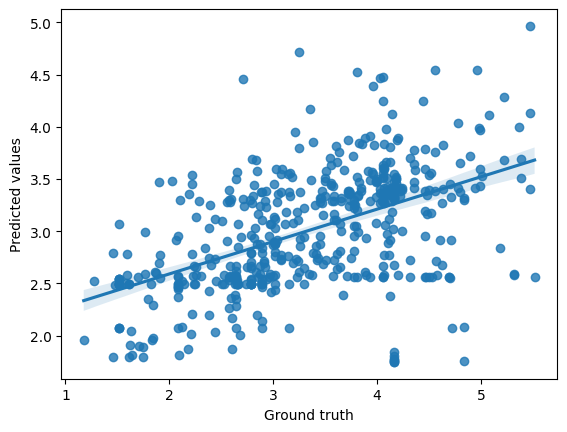

In [34]:
fig = sns.regplot(x=data.y[data.test_mask].numpy(), y=y_pred)
fig.set(xlabel='Ground truth', ylabel='Predicted values')